# Build an Artificial Neural Network Model with Back Propagation

#### 1. Load the data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../ML Data.csv", dtype = {"ROLL NO.": str})
df.columns = df.columns.str.strip()  # remove stray leading/trailing spaces from headers
print (df.head())
print (df.shape)


       ROLL NO. GENDER  SOFTWARE ENGINEER   TOC  COMPUTER NETWORK  \
0  240104010001      M               30.0  30.0              30.0   
1  240104010002      F               30.0  40.0              45.0   
2  240104010003      M               38.0  38.0              38.0   
3  240104010004      M               59.0  55.0              57.0   
4  240104010005      M               30.0  30.0              30.0   

   MACHINE LEARNING  DATA WAREHOUSE GRADE RESULT  
0              30.0            30.0     C   PASS  
1              40.0            35.0     B   Pass  
2              38.0            38.0     B   Pass  
3              58.0            54.0     A   pass  
4              30.0            30.0     C   Pass  
(86, 9)


#### 2. Clean the data

In [4]:
numeric_cols = ['SOFTWARE ENGINEER', 'TOC', 'COMPUTER NETWORK', 'MACHINE LEARNING', 'DATA WAREHOUSE']

df['GENDER'] = df['GENDER'].str.strip().str.upper()
df['RESULT'] = df['RESULT'].str.strip().str.upper()
df['GRADE'] = df['GRADE'].str.strip().str.upper()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

for col in ['GENDER', 'RESULT', 'GRADE']:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.dropna(subset=['ROLL NO.'])
print(df.isnull().sum())
print("\nRESULT value counts:")
print(df['RESULT'].value_counts())

ROLL NO.             0
GENDER               0
SOFTWARE ENGINEER    0
TOC                  0
COMPUTER NETWORK     0
MACHINE LEARNING     0
DATA WAREHOUSE       0
GRADE                0
RESULT               0
dtype: int64

RESULT value counts:
RESULT
PASS         66
FAIL          4
DISCHARGE     1
Name: count, dtype: int64


#### 3. Define target (y)
Predict **RESULT** from the subject marks. As in the earlier practicals, any class with fewer than 2 samples is dropped since a model cannot learn or be evaluated on a single example.

In [5]:
MIN_SAMPLES_PER_CLASS = 2

class_counts = df['RESULT'].value_counts()
rare_classes = class_counts[class_counts < MIN_SAMPLES_PER_CLASS].index.tolist()

if rare_classes:
    print(f"Dropping rare class(es) with < {MIN_SAMPLES_PER_CLASS} samples: {rare_classes}")
    df = df[~df['RESULT'].isin(rare_classes)]

print(df['RESULT'].value_counts())

Dropping rare class(es) with < 2 samples: ['DISCHARGE']
RESULT
PASS    66
FAIL     4
Name: count, dtype: int64


#### 4. Encode target and define features

In [6]:
from sklearn.preprocessing import LabelEncoder

le_result = LabelEncoder()
df['RESULT_ENCODED'] = le_result.fit_transform(df['RESULT'])
print(dict(zip(le_result.classes_, le_result.transform(le_result.classes_))))

X = df[numeric_cols]
y = df['RESULT_ENCODED']

{'FAIL': np.int64(0), 'PASS': np.int64(1)}


#### 5. Train-test split

In [7]:
from sklearn.model_selection import train_test_split

min_class_count = y.value_counts().min()
stratify_arg = y if min_class_count >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_arg
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (56, 5)
Test shape: (14, 5)


#### 6. Feature scaling
Neural networks train far more reliably on standardized inputs — large raw values can cause unstable gradients during back propagation.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 7. Build and train the ANN
`MLPClassifier` is a fully-connected feedforward neural network trained using back propagation (gradient descent on the error, propagated backward through each layer). Here we use two hidden layers of 8 and 4 neurons with the ReLU activation function.

In [9]:
from sklearn.neural_network import MLPClassifier

ann_model = MLPClassifier(
    hidden_layer_sizes=(8, 4),   # two hidden layers: 8 neurons then 4 neurons
    activation='relu',
    solver='adam',               # adam optimizer performs the back propagation weight updates
    max_iter=2000,
    random_state=42
)

ann_model.fit(X_train_scaled, y_train)
print(f"Training stopped after {ann_model.n_iter_} iterations")

Training stopped after 766 iterations


#### 8. Visualize the training loss curve
Shows how the error decreases over training iterations as back propagation updates the weights.

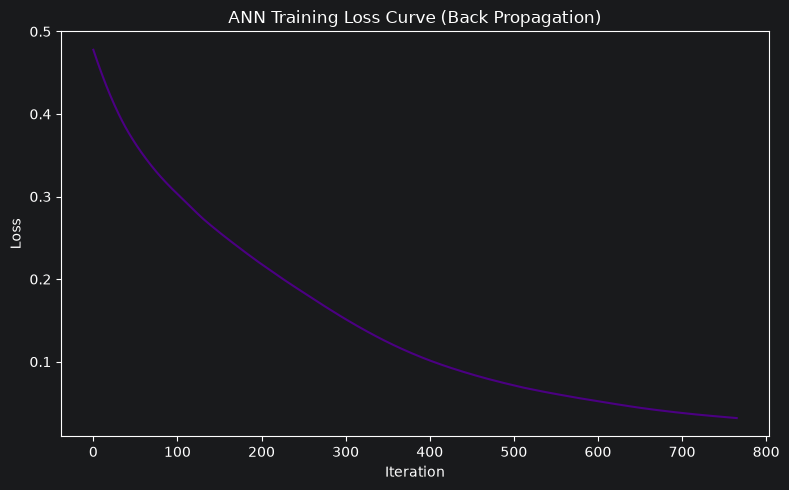

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(ann_model.loss_curve_, color='indigo')
plt.title('ANN Training Loss Curve (Back Propagation)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

#### 9. Evaluate the model

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = ann_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_result.classes_, zero_division=0))

Accuracy: 0.9286

Classification Report:
              precision    recall  f1-score   support

        FAIL       0.00      0.00      0.00         1
        PASS       0.93      1.00      0.96        13

    accuracy                           0.93        14
   macro avg       0.46      0.50      0.48        14
weighted avg       0.86      0.93      0.89        14



#### 10. Confusion matrix

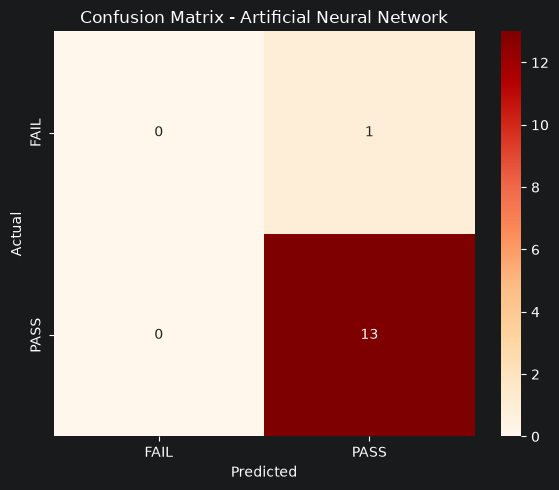

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd',
            xticklabels=le_result.classes_, yticklabels=le_result.classes_)
plt.title('Confusion Matrix - Artificial Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#### 11. Predict on a new/unseen student record

In [13]:
new_student = pd.DataFrame([[45, 50, 48, 52, 47]], columns=numeric_cols)
new_student_scaled = scaler.transform(new_student)

prediction = ann_model.predict(new_student_scaled)
prediction_proba = ann_model.predict_proba(new_student_scaled)

print("Predicted result:", le_result.inverse_transform(prediction)[0])
print("Class probabilities:", dict(zip(le_result.classes_, prediction_proba[0])))

Predicted result: PASS
Class probabilities: {'FAIL': np.float64(0.015840564614091335), 'PASS': np.float64(0.9841594353859087)}
